## Data exploration

### Installs

In [ ]:
%pip install networkx matplotlib numpy ipywidgets

#### Imports

In [15]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
from itertools import combinations

#### 1. Company hierarchy

- graph.json

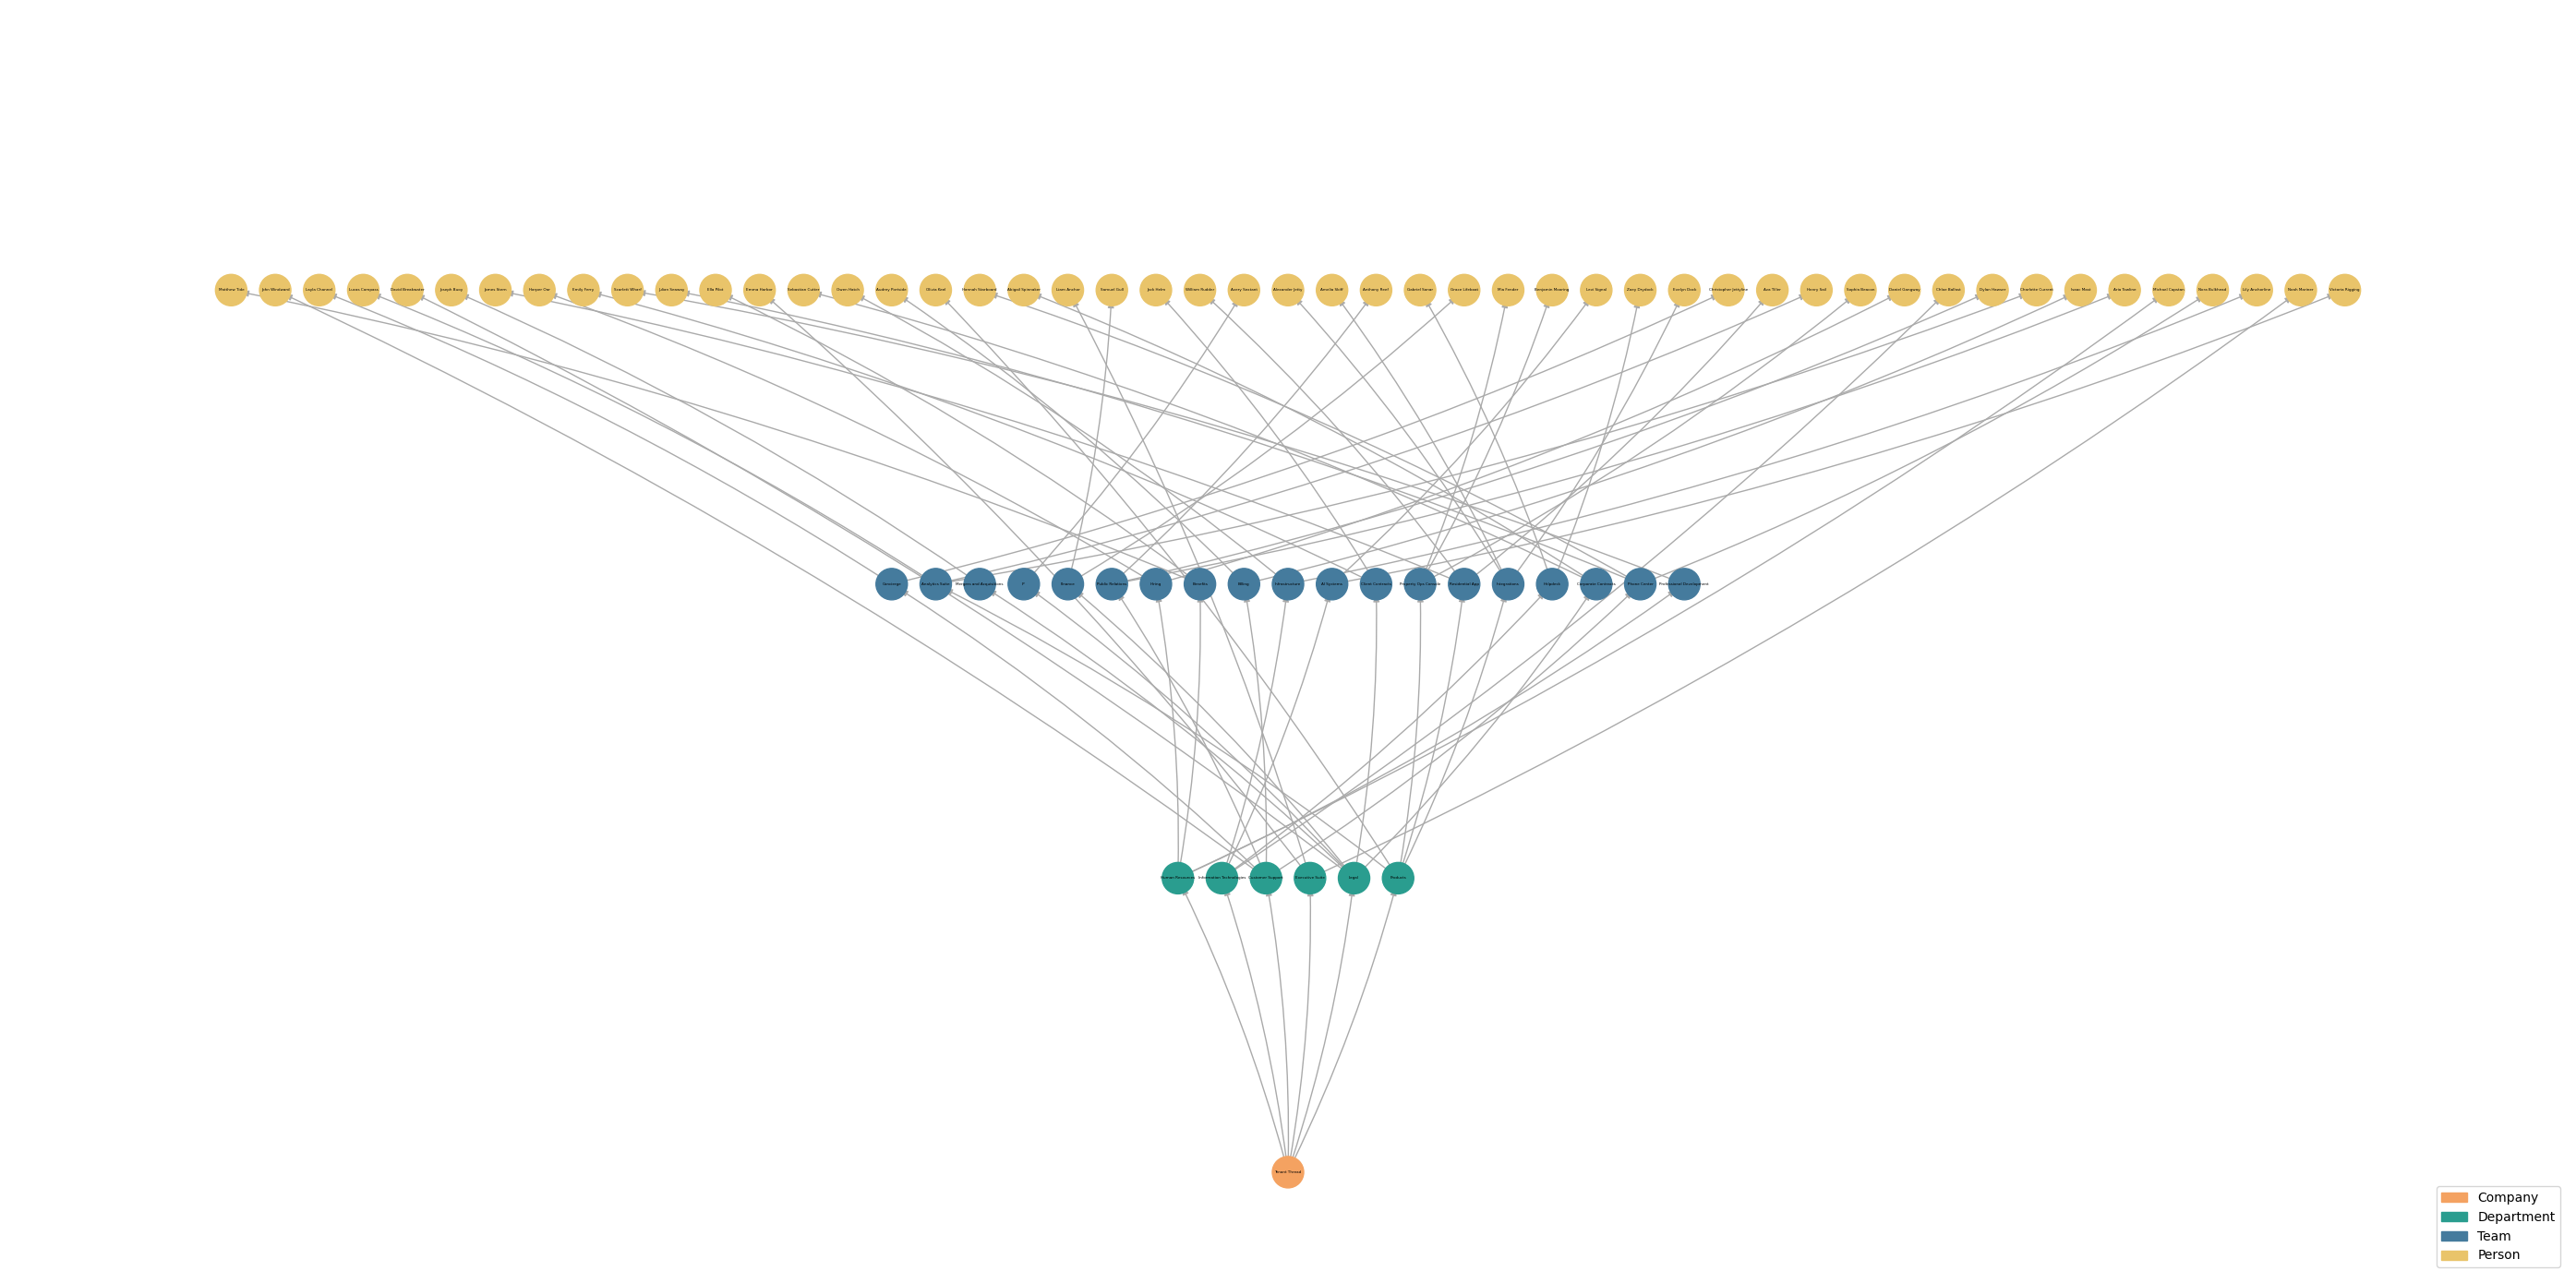

In [23]:
with open("../data/graph.json") as f:
    data = json.load(f)

G = nx.DiGraph()

LAYER = {"company": 0, "department": 1, "team": 2, "person": 3}
COLOR = {"company": "#F4A261", "department": "#2A9D8F", "team": "#457B9D", "person": "#E9C46A"}

for node in data["nodes"]:
    G.add_node(node["id"], **node, subset=LAYER[node["type"]])

for edge in data["edges"]:
    G.add_edge(edge["source"], edge["target"], relation=edge["relation"])

pos = nx.multipartite_layout(G, subset_key="subset", align="horizontal", scale=3)

node_colors = [COLOR[G.nodes[n]["type"]] for n in G.nodes]
labels = {n: G.nodes[n]["label"] for n in G.nodes}

fig, ax = plt.subplots(figsize=(28, 14))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=3, ax=ax)
nx.draw_networkx_edges(
    G, pos,
    edge_color="#aaa",
    arrows=True,
    arrowsize=10,
    connectionstyle="arc3,rad=0.05",
    ax=ax,
)

legend = [mpatches.Patch(color=c, label=t.capitalize()) for t, c in COLOR.items()]
ax.legend(handles=legend, loc="lower right", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

#### 2. Interactions visualization

- interactions.json

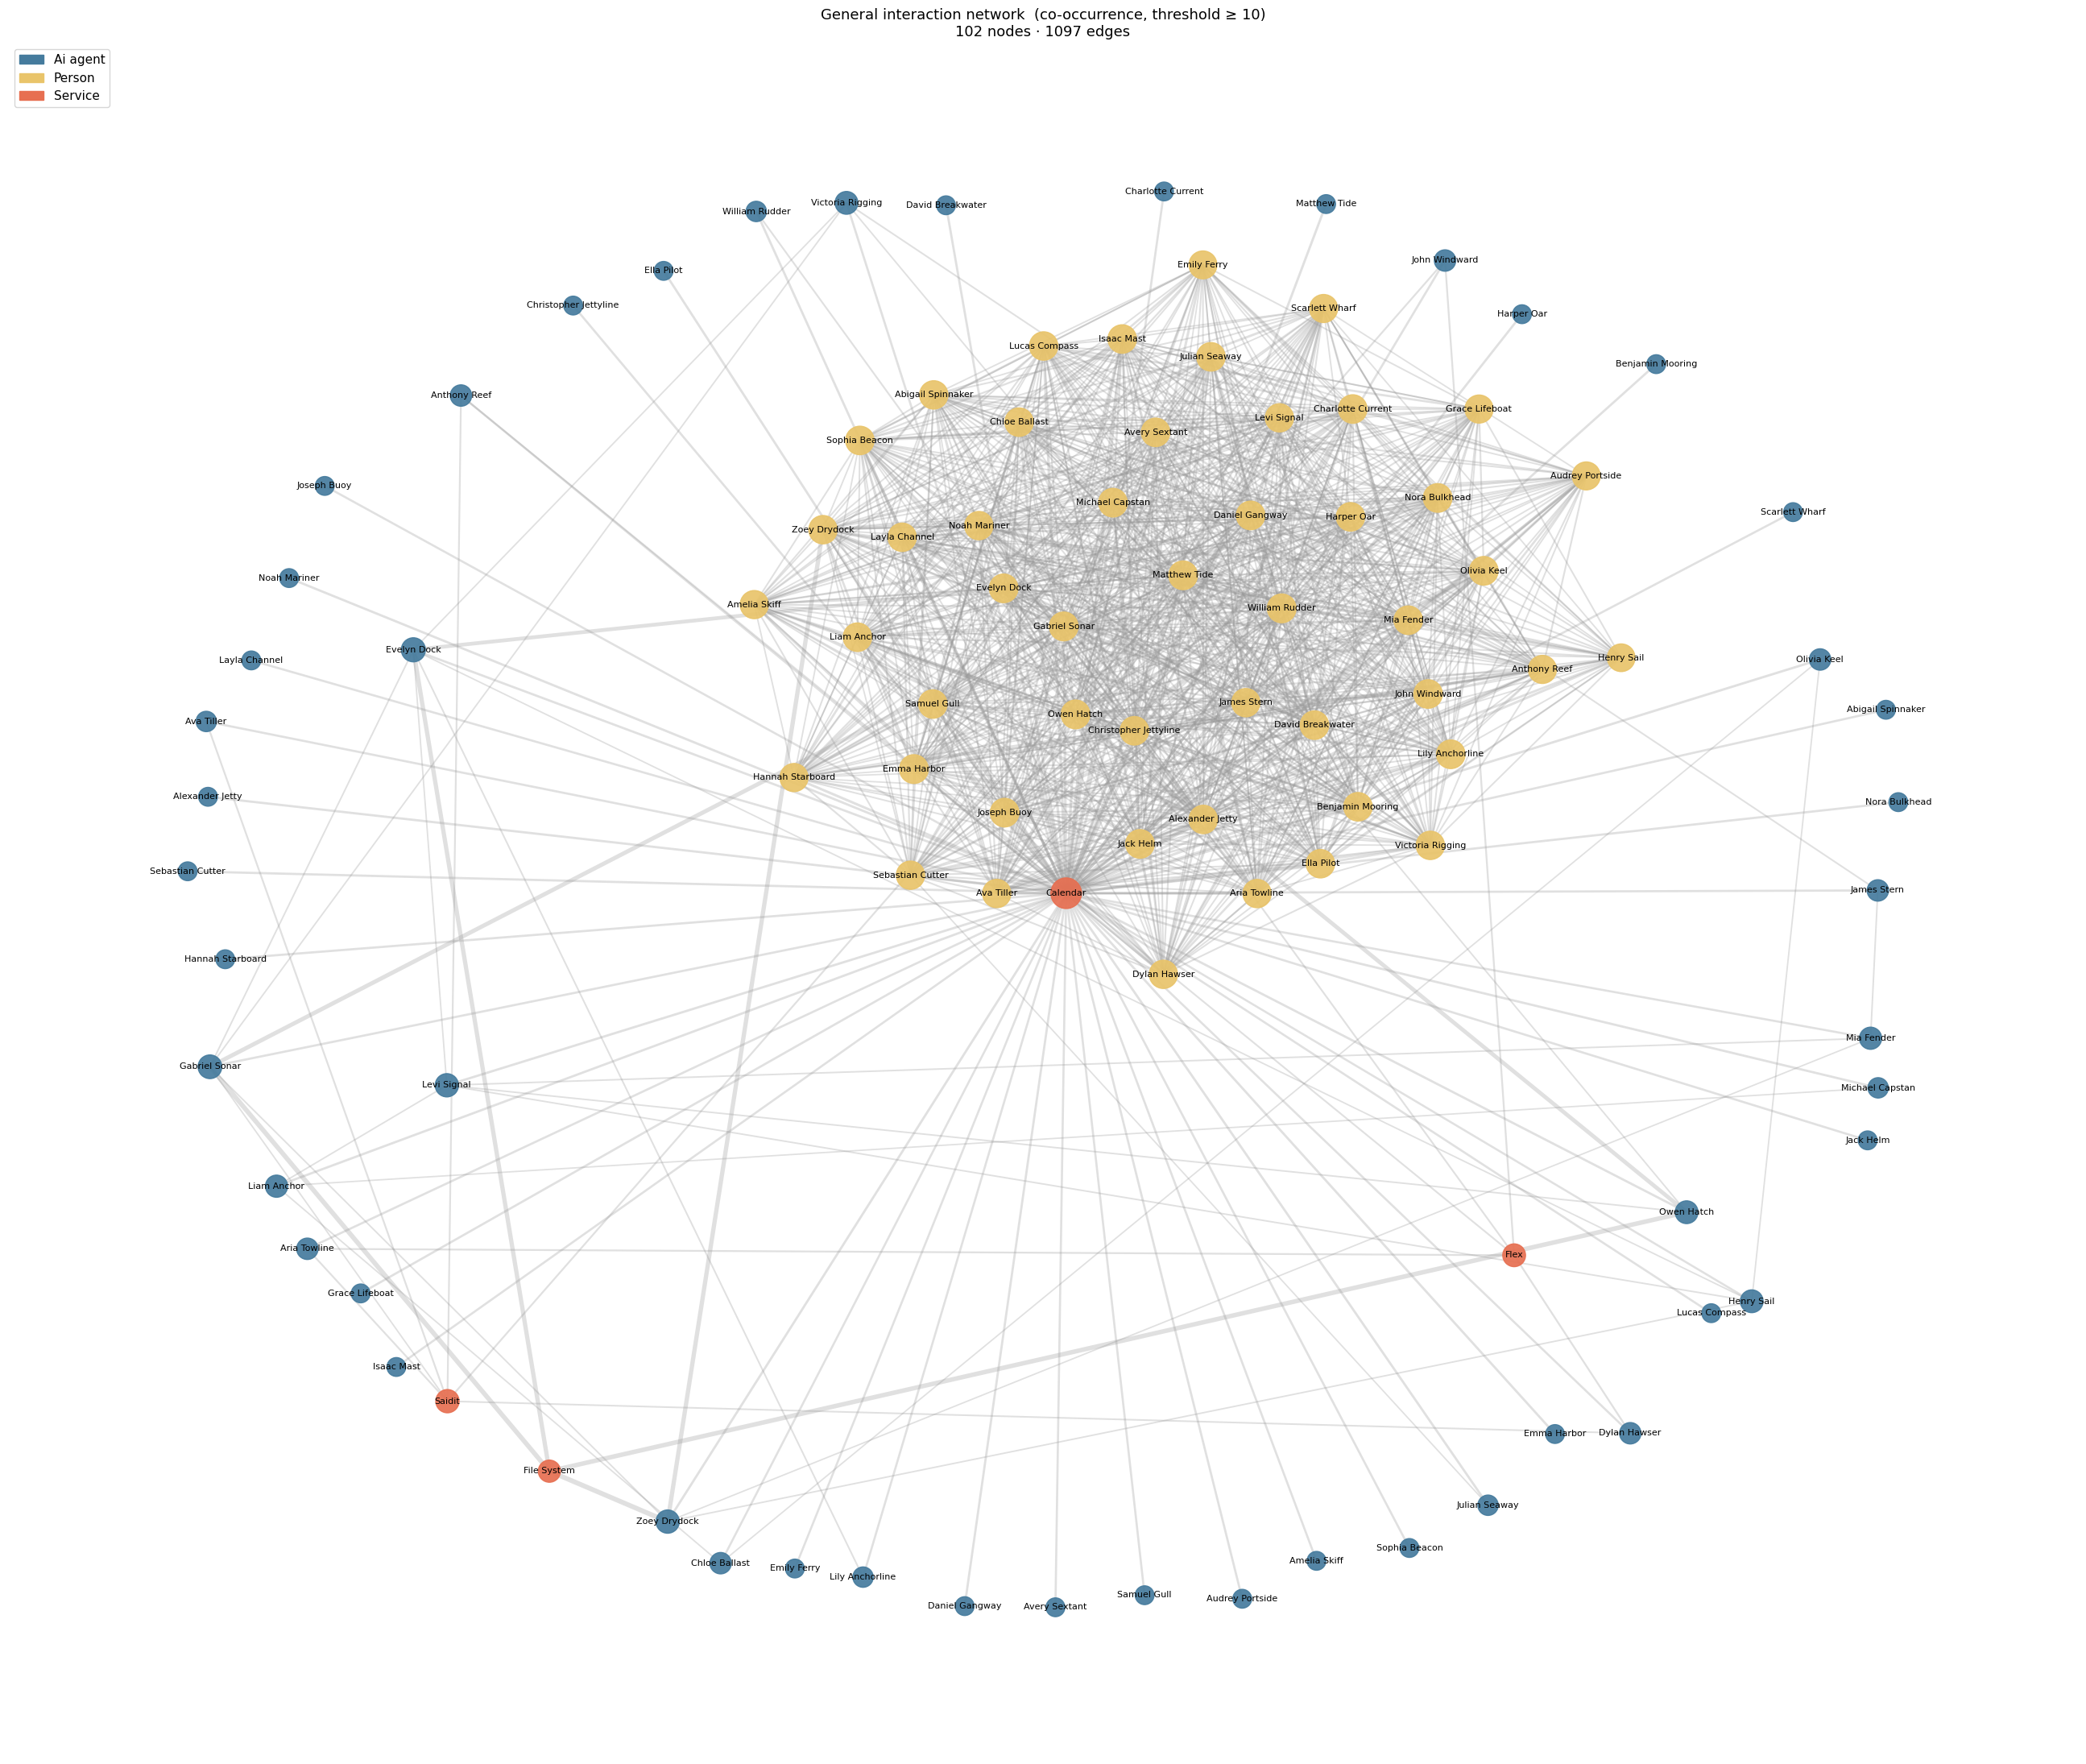

In [ ]:
from itertools import combinations

with open("../data/interactions.json") as f:
    events = json.load(f)["events"]
    
edge_w = Counter()
for e in events:
    parties = list(set(e["parties"]))
    for a, b in combinations(sorted(parties), 2):
        edge_w[(a, b)] += 1

G_net = nx.Graph()
THRESHOLD = 10
for (a, b), w in edge_w.items():
    if w >= THRESHOLD:
        G_net.add_edge(a, b, weight=w)

NCOLOR = {"agent": "#457B9D", "person": "#E9C46A", "service": "#E76F51"}

def node_kind(n):
    if n.startswith("Agent/") or n.startswith("agent:"): return "agent"
    if n.startswith("person:"): return "person"
    return "service"

def short_label(n):
    return (n.replace("Agent/person:", "").replace("agent:person:", "")
             .replace("person:", "").replace("world:", "").replace("system:", "")
             .replace("_", " ").title())

node_colors = [NCOLOR[node_kind(n)] for n in G_net.nodes]
node_sizes  = [200 + np.log1p(G_net.degree(n)) * 120 for n in G_net.nodes]
labels_net  = {n: short_label(n) for n in G_net.nodes}
weights     = np.array([G_net[u][v]["weight"] for u, v in G_net.edges])
edge_widths = np.log1p(weights) / np.log1p(weights.max()) * 4 + 0.3

pos = nx.spring_layout(G_net, seed=42, k=5.0, iterations=200, weight=None)

fig, ax = plt.subplots(figsize=(26, 22))
nx.draw_networkx_edges(G_net, pos, width=edge_widths, alpha=0.3, edge_color="#999", ax=ax)
nx.draw_networkx_nodes(G_net, pos, node_color=node_colors, node_size=node_sizes, alpha=0.92, ax=ax)
nx.draw_networkx_labels(G_net, pos, labels=labels_net, font_size=8, ax=ax)

legend_handles = [mpatches.Patch(color=c, label=k.replace("agent", "AI Agent").capitalize())
                  for k, c in NCOLOR.items()]
ax.legend(handles=legend_handles, loc="upper left", fontsize=11)
ax.set_title(
    f"General interaction network  (co-occurrence, threshold ≥ {THRESHOLD})\n"
    f"{G_net.number_of_nodes()} nodes · {G_net.number_of_edges()} edges",
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.show()

#### 3. AI events — interactive time preview